<a href="https://colab.research.google.com/github/siddhi-works/ai-chest-xray-disease-detection/blob/main/Covid_19_Xray_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
import kagglehub

path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")

print(path)

Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
/kaggle/input/covid19-radiography-database


In [ ]:
DATASET_PATH = path + "/COVID-19_Radiography_Dataset"

In [ ]:
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print(train_data.class_indices)  # check classes

Found 33866 images belonging to 4 classes.
Found 8464 images belonging to 4 classes.
{'COVID': 0, 'Lung_Opacity': 1, 'Normal': 2, 'Viral Pneumonia': 3}


In [ ]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)

# 🔥 AUTO FIX FOR CLASS COUNT
num_classes = train_data.num_classes
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 156, 156,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 75, 75,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 75, 75,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 75, 75,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 77, 77,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 38, 38,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 38, 38,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 38, 38,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 38, 38,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 38, 38,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 38, 38,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 38, 38,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 38, 38,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 38, 38,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 38, 38,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 38, 38,    │      1,024 │ conv2_block1_3_c

 Total params: 23,719,108 (90.48 MB)

 Trainable params: 131,396 (513.27 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,              # stop if no improvement for 5 epochs
    restore_best_weights=True
)

history = model.fit(
    train_data,
    epochs=30,               # 🔥 increased epochs
    validation_data=val_data,
    callbacks=[early_stop]
)

Epoch 1/30
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 123s 116ms/step - accuracy: 0.7875 - loss: 0.5319 - val_accuracy: 0.8891 - val_loss: 0.3099
Epoch 2/30
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 123s 116ms/step - accuracy: 0.7916 - loss: 0.5253 - val_accuracy: 0.9052 - val_loss: 0.2721
Epoch 3/30
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 124s 117ms/step - accuracy: 0.7951 - loss: 0.5116 - val_accuracy: 0.9060 - val_loss: 0.2845
Epoch 4/30
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 122s 115ms/step - accuracy: 0.7956 - loss: 0.5096 - val_accuracy: 0.9143 - val_loss: 0.2728
Epoch 5/30
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 121s 114ms/step - accuracy: 0.8002 - loss: 0.5046 - val_accuracy: 0.9093 - val_loss: 0.2879
Epoch 6/30
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 123s 116ms/step - accuracy: 0.8014 - loss: 0.5000 - val_accuracy: 0.9143 - val_loss: 0.2914
Epoch 7/30
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 126s 119ms/step - accuracy: 0.8035 - loss: 0.4909 - val_accuracy: 0.9093 - val_loss: 0.3061


In [ ]:
# Unfreeze last 50 layers (slightly more learning power)
for layer in base_model.layers[-50:]:
    layer.trainable = True

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.evaluate(val_data)

265/265 ━━━━━━━━━━━━━━━━━━━━ 38s 123ms/step - accuracy: 0.8971 - loss: 0.2939


[0.29392367601394653, 0.8970935940742493]

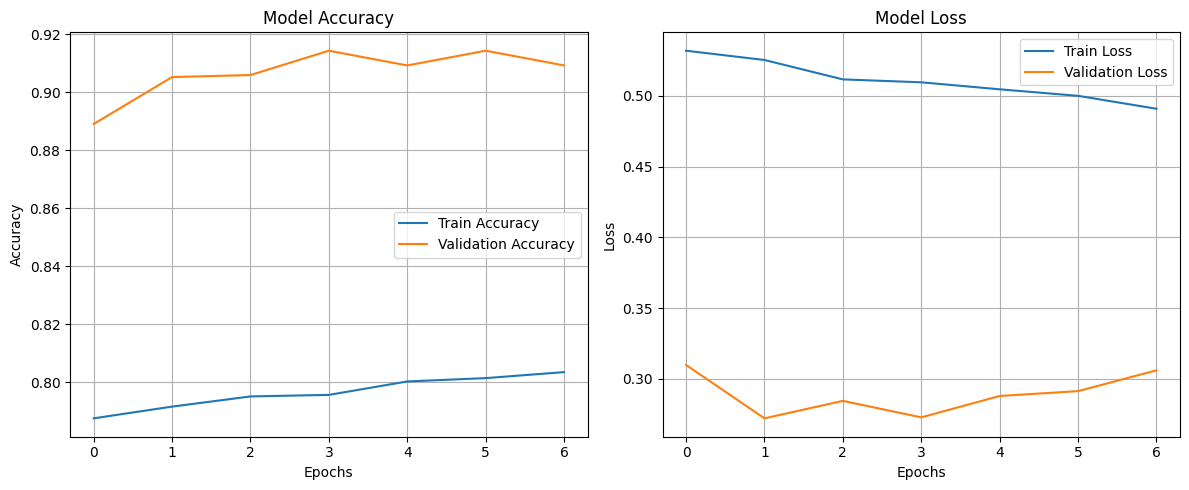

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Found 8464 images belonging to 4 classes.
265/265 ━━━━━━━━━━━━━━━━━━━━ 30s 114ms/step

✅ Validation Accuracy: 89.71%



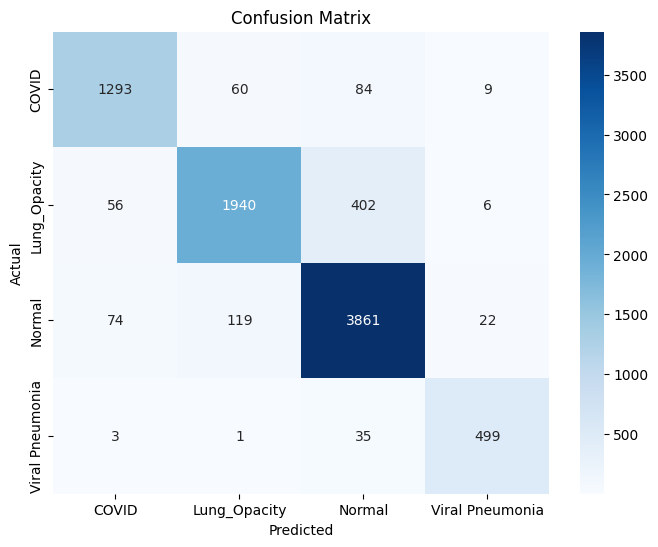


📊 Classification Report:

                 precision    recall  f1-score   support

          COVID       0.91      0.89      0.90      1446
   Lung_Opacity       0.92      0.81      0.86      2404
         Normal       0.88      0.95      0.91      4076
Viral Pneumonia       0.93      0.93      0.93       538

       accuracy                           0.90      8464
      macro avg       0.91      0.89      0.90      8464
   weighted avg       0.90      0.90      0.90      8464



In [ ]:
# 🔥 IMPORTANT: recreate validation generator WITHOUT shuffle
val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Predictions
pred = model.predict(val_data)
y_pred = np.argmax(pred, axis=1)
y_true = val_data.classes

# Class names
class_names = list(val_data.class_indices.keys())

# 🔹 Accuracy
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_true, y_pred)
print(f"\n✅ Validation Accuracy: {acc*100:.2f}%\n")

# 🔹 Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 🔹 Classification Report
from sklearn.metrics import classification_report

print("\n📊 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'image.png', 'image (1).png', 'skin_cancer_cnn.keras', 'skin_cancer_cnn.h5']


In [ ]:
model.save("/content/drive/MyDrive/final_model.h5")
model.save("/content/drive/MyDrive/final_model.keras")

print("✅ Model saved to Google Drive")

✅ Model saved to Google Drive


In [ ]:
model.save("/content/final_model.h5")
model.save("/content/final_model.keras")

print("✅ Model saved locally in Colab")

✅ Model saved locally in Colab


In [ ]:
import pickle

class_names = list(train_data.class_indices.keys())

# Save to Drive
pickle.dump(class_names, open("/content/drive/MyDrive/class_names.pkl", "wb"))

# Save locally
pickle.dump(class_names, open("/content/class_names.pkl", "wb"))

print("✅ Class labels saved")

✅ Class labels saved


In [ ]:
from google.colab import files

files.download("/content/final_model.h5")
files.download("/content/final_model.keras")
files.download("/content/class_names.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


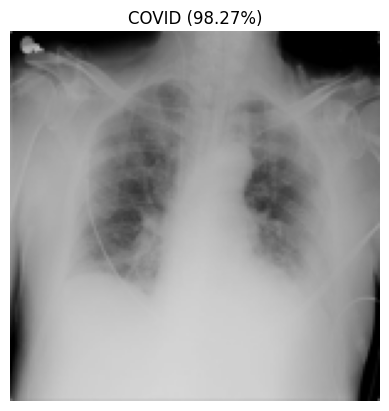

Prediction: COVID
Confidence: 98.27%


('COVID', np.float32(0.98274165))

In [ ]:
import cv2
import numpy as np
import pickle
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input

# =========================
# Load model + class names
# =========================
model = load_model("final_model.h5")

class_names = pickle.load(open("class_names.pkl", "rb"))

# =========================
# Prediction function
# =========================
def predict_image(image_path):
    img = cv2.imread(image_path)

    if img is None:
        raise ValueError(f"Image not found at: {image_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (150,150))

    img_pre = preprocess_input(img)
    img_pre = np.expand_dims(img_pre, axis=0)

    pred = model.predict(img_pre)
    idx = np.argmax(pred)

    label = class_names[idx]
    confidence = pred[0][idx]

    plt.imshow(img)
    plt.title(f"{label} ({confidence*100:.2f}%)")
    plt.axis('off')
    plt.show()

    print(f"Prediction: {label}")
    print(f"Confidence: {confidence*100:.2f}%")

    return label, confidence   # 🔥 ADD THIS LINE
# =========================
# Example (dataset image)
# =========================
import kagglehub
path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")

image_path = path + "/COVID-19_Radiography_Dataset/COVID/images/COVID-1.png"

predict_image(image_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


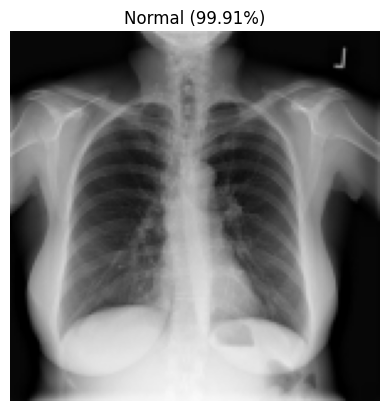

Prediction: Normal
Confidence: 99.91%
Predicted Label: Normal, Confidence Score: 99.91%


In [ ]:
image_path = path + "/COVID-19_Radiography_Dataset/Normal/images/Normal-10002.png"

label, confidence = predict_image(image_path)

print(f"Predicted Label: {label}, Confidence Score: {confidence*100:.2f}%")